# Лабораторная работа №4. Вариант 2

**Тема:** методы многомерного поиска.

**Параметры варианта 9:** $a = 150,\ b = 2,\ f_0 = 100,\ n = 3$.

Ограничения:

g1 = x1² + x2² - x3 - 1 ≤ 0
g2 = -x1 ≤ 0
g3 = -x2 ≤ 0
g4 = -x3 ≤ 0

Методы:
- Метод штрафных функций
- Метод барьерных функций
- Комбинированный метод штрафных и барьерных функций
- Метод модифицированных функций Лагранжа
- Метод проекции градиента

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


# Определение функции Розенброка и ограничений

In [5]:
a = 150
b = 2
f0 = 100
n = 3

def rosenbrock(x):
    """Функция Розенброка для n=3"""
    total = 0
    for i in range(n-1):
        total += a * (x[i]**2 - x[i+1])**2 + b * (x[i] - 1)**2
    return total + f0

def constraints(x):
    """Ограничения задачи"""
    x1, x2, x3 = x
    g = np.zeros(4)
    g[0] = x1**2 + x2**2 - x3 - 1  # g1 <= 0
    g[1] = -x1                      # g2 <= 0
    g[2] = -x2                      # g3 <= 0
    g[3] = -x3                      # g4 <= 0
    return g

def is_feasible(x, epsilon=1e-6):
    """Проверка допустимости точки"""
    g = constraints(x)
    return np.all(g <= epsilon)

# Метод безусловной минимизации (Нелдер-Мид)

In [6]:
def unconstrained_minimize(f, x0, bounds=None, max_iter=1000):
    """Метод Нелдера-Мида для безусловной минимизации"""
    result = minimize(f, x0, method='Nelder-Mead', 
                     options={'maxiter': max_iter, 'xatol': 1e-8, 'fatol': 1e-8})
    return result.x, result.fun

# 1. Метод штрафных функций (внешних штрафов)

In [7]:
def penalty_method(x0, r0=1.0, C=4.0, epsilon=1e-6, max_iter=50):
    """
    Метод внешних штрафных функций
    P(x, r) = (r/2) * sum(max(0, g_j(x))^2)
    """
    x_k = x0.copy()
    r_k = r0
    history = {'x': [], 'f': [], 'penalty': []}
    
    print("=" * 60)
    print("МЕТОД ШТРАФНЫХ ФУНКЦИЙ (ВНЕШНИХ ШТРАФОВ)")
    print("=" * 60)
    print(f"Начальная точка: {x_k}")
    print(f"Начальный параметр штрафа: {r_k}")
    print()
    
    for k in range(max_iter):
        # Вспомогательная функция со штрафом
        def F_penalty(x):
            f_val = rosenbrock(x)
            g = constraints(x)
            # Квадратичный штраф для нарушенных ограничений
            penalty = 0
            for j in range(len(g)):
                if g[j] > 0:
                    penalty += g[j]**2
            penalty *= r_k / 2
            return f_val + penalty
        
        # Поиск минимума вспомогательной функции
        x_new, f_val = unconstrained_minimize(F_penalty, x_k)
        
        # Вычисление штрафа
        g = constraints(x_new)
        P = 0
        for j in range(len(g)):
            if g[j] > 0:
                P += g[j]**2
        P *= r_k / 2
        
        history['x'].append(x_new.copy())
        history['f'].append(rosenbrock(x_new))
        history['penalty'].append(P)
        
        print(f"Итерация {k+1}: x = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
        print(f"  f(x) = {rosenbrock(x_new):.6f}, P(x,r) = {P:.6f}, r = {r_k:.2f}")
        
        # Проверка условия окончания
        if P <= epsilon:
            print(f"\nРешение найдено за {k+1} итераций")
            break
        
        # Увеличение параметра штрафа
        r_k *= C
        x_k = x_new.copy()
    
    print(f"Итоговое решение: x* = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
    print(f"f(x*) = {rosenbrock(x_new):.6f}")
    print(f"Допустимость: {is_feasible(x_new)}")
    print()
    
    return x_new, rosenbrock(x_new), history

# 2. Метод барьерных функций (внутренних штрафов)

In [8]:
def barrier_method(x0, r0=10.0, C=10.0, epsilon=1e-5, max_iter=50):

    # Проверка, что начальная точка внутри допустимой области
    if not np.all(constraints(x0) < 0):
        print("начальная точка должна быть строго внутри допустимой области")
        # Поиск допустимой точки
        x0 = find_feasible_point()
        print(f"Найдена допустимая точка: {x0}")
    
    x_k = x0.copy()
    r_k = r0
    history = {'x': [], 'f': [], 'penalty': []}
    
    print("=" * 60)
    print("МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ВНУТРЕННИХ ШТРАФОВ)")
    print("=" * 60)
    print(f"Начальная точка: {x_k}")
    print(f"Начальный параметр барьера: {r_k}")
    print()
    
    for k in range(max_iter):
        # Вспомогательная функция с барьером (логарифмический)
        def F_barrier(x):
            g = constraints(x)
            # Проверка на допустимость (все g < 0)
            if np.any(g >= -1e-12):
                return 1e10  # Большое число, если точка недопустима
            f_val = rosenbrock(x)
            # Логарифмический барьер
            barrier = -r_k * np.sum(np.log(-g))
            return f_val + barrier
        
        # Поиск минимума
        x_new, _ = unconstrained_minimize(F_barrier, x_k)
        
        # Вычисление барьерной составляющей
        g = constraints(x_new)
        if np.any(g >= -1e-12):
            P = 1e10
        else:
            P = -r_k * np.sum(np.log(-g))
        
        history['x'].append(x_new.copy())
        history['f'].append(rosenbrock(x_new))
        history['penalty'].append(abs(P) if P < 1e9 else 1e10)
        
        print(f"Итерация {k+1}: x = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
        print(f"  f(x) = {rosenbrock(x_new):.6f}, |P(x,r)| = {abs(P) if P < 1e9 else 1e10:.6f}, r = {r_k:.6f}")
        
        # Проверка условия окончания
        if abs(P) <= epsilon and P < 1e9:
            print(f"\nРешение найдено за {k+1} итераций")
            break
        
        # Уменьшение параметра барьера
        r_k /= C
        x_k = x_new.copy()
    
    print(f"Итоговое решение: x* = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
    print(f"f(x*) = {rosenbrock(x_new):.6f}")
    print(f"Допустимость: {is_feasible(x_new)}")
    print()
    
    return x_new, rosenbrock(x_new), history

def find_feasible_point():
    # Для нашего случая: x1>0, x2>0, x3>0, x1^2+x2^2-x3-1<0
    for x1 in np.linspace(0.1, 2, 20):
        for x2 in np.linspace(0.1, 2, 20):
            for x3 in np.linspace(0.1, 5, 20):
                x = np.array([x1, x2, x3])
                g = constraints(x)
                if np.all(g < -1e-3):
                    return x
    return np.array([0.1, 0.1, 0.5])

# 3. Комбинированный метод штрафных и барьерных функций

In [9]:
def combined_method(x0, r0_ext=1.0, r0_int=10.0, C=5.0, epsilon=1e-6, max_iter=50):
    """
    Комбинированный метод: внешний штраф для нарушенных ограничений
    и внутренний барьер для соблюдения границ
    """
    x_k = x0.copy()
    r_ext = r0_ext  # Параметр внешнего штрафа
    r_int = r0_int  # Параметр внутреннего барьера
    history = {'x': [], 'f': [], 'penalty': []}
    
    print("=" * 60)
    print("КОМБИНИРОВАННЫЙ МЕТОД ШТРАФНЫХ И БАРЬЕРНЫХ ФУНКЦИЙ")
    print("=" * 60)
    print(f"Начальная точка: {x_k}")
    print()
    
    for k in range(max_iter):
        def F_combined(x):
            f_val = rosenbrock(x)
            g = constraints(x)
            
            # Внешний штраф (для g > 0)
            ext_penalty = 0
            for j in range(len(g)):
                if g[j] > 0:
                    ext_penalty += g[j]**2
            
            # Внутренний барьер (для g < 0)
            int_barrier = 0
            for j in range(len(g)):
                if g[j] < -1e-12:
                    int_barrier -= r_int * np.log(-g[j])
                elif g[j] >= -1e-12:
                    return 1e10
            
            return f_val + (r_ext/2) * ext_penalty + int_barrier
        
        x_new, f_val = unconstrained_minimize(F_combined, x_k)
        
        g = constraints(x_new)
        ext_penalty = sum(max(0, g_j)**2 for g_j in g) * r_ext / 2
        
        history['x'].append(x_new.copy())
        history['f'].append(rosenbrock(x_new))
        history['penalty'].append(ext_penalty)
        
        print(f"Итерация {k+1}: x = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
        print(f"  f(x) = {rosenbrock(x_new):.6f}, P_ext = {ext_penalty:.6f}")
        
        if ext_penalty <= epsilon:
            print(f"\nРешение найдено за {k+1} итераций")
            break
        
        r_ext *= C
        r_int /= C
        x_k = x_new.copy()
    
    print(f"Итоговое решение: x* = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
    print(f"f(x*) = {rosenbrock(x_new):.6f}")
    print(f"Допустимость: {is_feasible(x_new)}")
    print()
    
    return x_new, rosenbrock(x_new), history

# 4. Метод модифицированных функций Лагранжа

In [10]:
def augmented_lagrangian_method(x0, r0=1.0, C=4.0, epsilon=1e-6, max_iter=50):
    """
    Метод модифицированных (расширенных) функций Лагранжа
    Для ограничений-неравенств: mu_j^(k+1) = max(0, mu_j^k + r^k * g_j(x*))
    """
    x_k = x0.copy()
    r_k = r0
    # Начальные множители Лагранжа
    mu_k = np.zeros(4)  # 4 ограничения-неравенства
    history = {'x': [], 'f': [], 'penalty': []}
    
    print("=" * 60)
    print("МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА")
    print("=" * 60)
    print(f"Начальная точка: {x_k}")
    print(f"Начальные множители: {mu_k}")
    print()
    
    for k in range(max_iter):
        def F_lagrange(x):
            f_val = rosenbrock(x)
            g = constraints(x)
            
            # Модифицированная функция Лагранжа для неравенств
            lagrange_term = 0
            for j in range(len(g)):
                term = mu_k[j] + r_k * g[j]
                if term > 0:
                    lagrange_term += (term**2 - mu_k[j]**2) / (2 * r_k)
            
            return f_val + lagrange_term
        
        # Поиск минимума
        x_new, _ = unconstrained_minimize(F_lagrange, x_k)
        
        # Вычисление штрафной составляющей
        g = constraints(x_new)
        P = 0
        for j in range(len(g)):
            term = mu_k[j] + r_k * g[j]
            if term > 0:
                P += (term**2 - mu_k[j]**2) / (2 * r_k)
        
        history['x'].append(x_new.copy())
        history['f'].append(rosenbrock(x_new))
        history['penalty'].append(abs(P))
        
        print(f"Итерация {k+1}: x = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
        print(f"  f(x) = {rosenbrock(x_new):.6f}, P = {abs(P):.6f}")
        print(f"  Множители: {mu_k}")
        
        # Проверка условия окончания
        if abs(P) <= epsilon:
            print(f"\nРешение найдено за {k+1} итераций")
            break
        
        # Обновление параметров
        g = constraints(x_new)
        for j in range(len(g)):
            mu_k[j] = max(0, mu_k[j] + r_k * g[j])
        
        r_k *= C
        x_k = x_new.copy()
    
    print(f"Итоговое решение: x* = [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
    print(f"f(x*) = {rosenbrock(x_new):.6f}")
    print(f"Допустимость: {is_feasible(x_new)}")
    print(f"Финальные множители Лагранжа: {mu_k}")
    print()
    
    return x_new, rosenbrock(x_new), history

# 5. Метод проекции градиента

In [ ]:
def gradient(f, x, h=1e-6):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus = x.copy()
        x_plus[i] += h
        x_minus = x.copy()
        x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad

def jacobian_constraints(x, h=1e-6):
    m = 4  # количество ограничений
    jac = np.zeros((m, len(x)))
    for j in range(m):
        def g_j(x_vec):
            return constraints(x_vec)[j]
        for i in range(len(x)):
            x_plus = x.copy()
            x_plus[i] += h
            x_minus = x.copy()
            x_minus[i] -= h
            jac[j, i] = (g_j(x_plus) - g_j(x_minus)) / (2 * h)
    return jac

def gradient_projection_method(x0, epsilon1=-1e-4, epsilon2=1e-5, max_iter=100):
    x_k = x0.copy()
    history = {'x': [], 'f': []}
    M = max_iter
    
    print("=" * 60)
    print("МЕТОД ПРОЕКЦИИ ГРАДИЕНТА")
    print("=" * 60)
    print(f"Начальная точка: {x_k}")
    print()
    
    # Шаг 1: Инициализация
    x_k = x0.copy()
    
    for iteration in range(M):
        # Шаг 4: Вычисление ограничений в текущей точке
        g_k = constraints(x_k)
        
        # Шаг 5: Проверка активных ограничений
        active = []
        for j in range(len(g_k)):
            if epsilon1 <= g_k[j] <= 0:
                active.append(j)
        
        grad_f = gradient(rosenbrock, x_k)
        
        if len(active) == 0:
            # Нет активных ограничений - движение по антиградиенту
            if np.linalg.norm(grad_f) < epsilon2:
                print(f"Градиент мал, остановка на итерации {iteration}")
                break
            
            # Линейный поиск
            alpha = 0.1
            for _ in range(20):
                x_new = x_k - alpha * grad_f
                if is_feasible(x_new) or np.all(constraints(x_new) <= 1e-6):
                    if rosenbrock(x_new) < rosenbrock(x_k):
                        break
                alpha /= 2
            
            x_new = x_k - alpha * grad_f
        else:
            # Есть активные ограничения
            A_k = jacobian_constraints(x_k)[active]
            
            # Проектор на касательное подпространство
            try:
                AAT_inv = np.linalg.inv(A_k @ A_k.T)
                P = np.eye(len(x_k)) - A_k.T @ AAT_inv @ A_k
                delta_x = -P @ grad_f
            except np.linalg.LinAlgError:
                delta_x = -grad_f
            
            if np.linalg.norm(delta_x) < epsilon2:
                # Шаг 9: Проверка множителей Лагранжа
                try:
                    AAT_inv = np.linalg.inv(A_k @ A_k.T)
                    lambda_k = -AAT_inv @ A_k @ grad_f
                    
                    if np.all(lambda_k >= -1e-6):
                        print(f"Условия ККТ выполнены на итерации {iteration}")
                        break
                    else:
                        # Удаление ограничения с наибольшим отрицательным множителем
                        worst_idx = np.argmin(lambda_k)
                        active.pop(worst_idx)
                        if len(active) > 0:
                            A_k = jacobian_constraints(x_k)[active]
                            AAT_inv = np.linalg.inv(A_k @ A_k.T)
                            P = np.eye(len(x_k)) - A_k.T @ AAT_inv @ A_k
                            delta_x = -P @ grad_f
                        else:
                            delta_x = -grad_f
                except np.linalg.LinAlgError:
                    delta_x = -grad_f
            
            # Линейный поиск
            alpha = 0.1
            for _ in range(30):
                x_test = x_k + alpha * delta_x
                if is_feasible(x_test, epsilon=1e-4):
                    if rosenbrock(x_test) < rosenbrock(x_k):
                        break
                alpha /= 2
            
            x_new = x_k + alpha * delta_x
        
        history['x'].append(x_k.copy())
        history['f'].append(rosenbrock(x_k))
        
        if iteration % 5 == 0:
            print(f"Итерация {iteration+1}: x = [{x_k[0]:.6f}, {x_k[1]:.6f}, {x_k[2]:.6f}]")
            print(f"  f(x) = {rosenbrock(x_k):.6f}, активных ограничений: {len(active)}")
        
        # Проверка сходимости
        if np.linalg.norm(x_new - x_k) < 1e-8:
            print(f"Сходимость по аргументу на итерации {iteration}")
            break
        
        x_k = x_new.copy()
    
    history['x'].append(x_k.copy())
    history['f'].append(rosenbrock(x_k))
    
    print(f"\nИтоговое решение: x* = [{x_k[0]:.6f}, {x_k[1]:.6f}, {x_k[2]:.6f}]")
    print(f"f(x*) = {rosenbrock(x_k):.6f}")
    print(f"Допустимость: {is_feasible(x_k)}")
    print(f"Активные ограничения в решении: {[j for j, g in enumerate(constraints(x_k)) if abs(g) < 1e-3]}")
    print()
    
    return x_k, rosenbrock(x_k), history

# Сравнительный анализ всех методов

In [12]:
print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ УСЛОВНОЙ ОПТИМИЗАЦИИ")
print("Вариант 2: a=150, b=2, f0=100, n=3")
print("=" * 70)

# Начальная точка
x0 = np.array([0.5, 0.5, 1.0])

print(f"\nПроверка начальной точки:")
print(f"x0 = {x0}")
print(f"f(x0) = {rosenbrock(x0):.6f}")
print(f"Ограничения: {constraints(x0)}")
print(f"Допустима: {is_feasible(x0)}\n")

# Словарь для хранения результатов
results = {}

# Метод 1: Штрафных функций
x_opt, f_opt, hist = penalty_method(x0, r0=0.1, C=5.0, epsilon=1e-6, max_iter=30)
results['Штрафных функций'] = {'x': x_opt, 'f': f_opt, 'hist': hist}

# Метод 2: Барьерных функций
x0_barrier = find_feasible_point()
print(f"Найдена допустимая точка для барьерного метода: {x0_barrier}")
x_opt, f_opt, hist = barrier_method(x0_barrier, r0=1.0, C=10.0, epsilon=1e-4, max_iter=30)
results['Барьерных функций'] = {'x': x_opt, 'f': f_opt, 'hist': hist}

# Метод 3: Комбинированный
x_opt, f_opt, hist = combined_method(x0, r0_ext=0.1, r0_int=1.0, C=5.0, epsilon=1e-6, max_iter=30)
results['Комбинированный'] = {'x': x_opt, 'f': f_opt, 'hist': hist}

# Метод 4: Модифицированных функций Лагранжа
x_opt, f_opt, hist = augmented_lagrangian_method(x0, r0=0.1, C=5.0, epsilon=1e-6, max_iter=30)
results['Мод. функций Лагранжа'] = {'x': x_opt, 'f': f_opt, 'hist': hist}

# Метод 5: Проекции градиента
x_opt, f_opt, hist = gradient_projection_method(x0, max_iter=100)
results['Проекции градиента'] = {'x': x_opt, 'f': f_opt, 'hist': hist}


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ УСЛОВНОЙ ОПТИМИЗАЦИИ
Вариант 2: a=150, b=2, f0=100, n=3

Проверка начальной точки:
x0 = [0.5 0.5 1. ]
f(x0) = 194.750000
Ограничения: [-1.5 -0.5 -0.5 -1. ]
Допустима: True

МЕТОД ШТРАФНЫХ ФУНКЦИЙ (ВНЕШНИХ ШТРАФОВ)
Начальная точка: [0.5 0.5 1. ]
Начальный параметр штрафа: 0.1

Итерация 1: x = [1.000000, 1.000000, 1.000000]
  f(x) = 100.000000, P(x,r) = 0.000000, r = 0.10

Решение найдено за 1 итераций
Итоговое решение: x* = [1.000000, 1.000000, 1.000000]
f(x*) = 100.000000
Допустимость: True

Найдена допустимая точка для барьерного метода: [0.1 0.1 0.1]
МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ВНУТРЕННИХ ШТРАФОВ)
Начальная точка: [0.1 0.1 0.1]
Начальный параметр барьера: 1.0

Итерация 1: x = [0.906185, 0.835107, 0.718698]
  f(x) = 100.169134, |P(x,r)| = 2.217840, r = 1.000000
Итерация 2: x = [0.945720, 0.896873, 0.807850]
  f(x) = 100.029895, |P(x,r)| = 0.259368, r = 0.100000
Итерация 3: x = [0.979340, 0.959748, 0.921952]
  f(x) = 100.004260, |P(x,r)| = 0.033198, r = 0.010

# Вывод итоговой сравнительной таблицы

In [ ]:
print("\n" + "=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МЕТОДОВ")
print("=" * 70)
print(f"{'Метод':<25} {'x1':<10} {'x2':<10} {'x3':<10} {'f(x*)':<12} {'Итерации':<10}")
print("-" * 70)

for name, res in results.items():
    x = res['x']
    f = res['f']
    iters = len(res['hist']['x'])
    print(f"{name:<25} {x[0]:<10.6f} {x[1]:<10.6f} {x[2]:<10.6f} {f:<12.6f} {iters:<10}")

print("-" * 70)


print("\nПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЙ:")
print(f"{'Метод':<25} {'Допустимость':<15} {'g1':<12} {'g2':<12} {'g3':<12} {'g4':<12}")
print("-" * 80)
for name, res in results.items():
    x = res['x']
    g = constraints(x)
    feasible = "ДА" if is_feasible(x) else "НЕТ"
    print(f"{name:<25} {feasible:<15} {g[0]:<12.6f} {g[1]:<12.6f} {g[2]:<12.6f} {g[3]:<12.6f}")


ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МЕТОДОВ
Метод                     x1         x2         x3         f(x*)        Итерации  
----------------------------------------------------------------------
Штрафных функций          1.000000   1.000000   1.000000   100.000000   1         
Барьерных функций         0.999297   0.998612   0.997250   100.000005   6         
Комбинированный           0.906185   0.835107   0.718698   100.169134   1         
Мод. функций Лагранжа     1.000000   1.000000   1.000000   100.000000   1         
Проекции градиента        0.889221   0.789768   0.622561   100.113279   101       
----------------------------------------------------------------------

ПРОВЕРКА ДОПУСТИМОСТИ РЕШЕНИЙ:
Метод                     Допустимость    g1           g2           g3           g4          
--------------------------------------------------------------------------------
Штрафных функций          ДА              0.000000     -1.000000    -1.000000    -1.000000   
Барьерных функций      

# Визуализация результатов

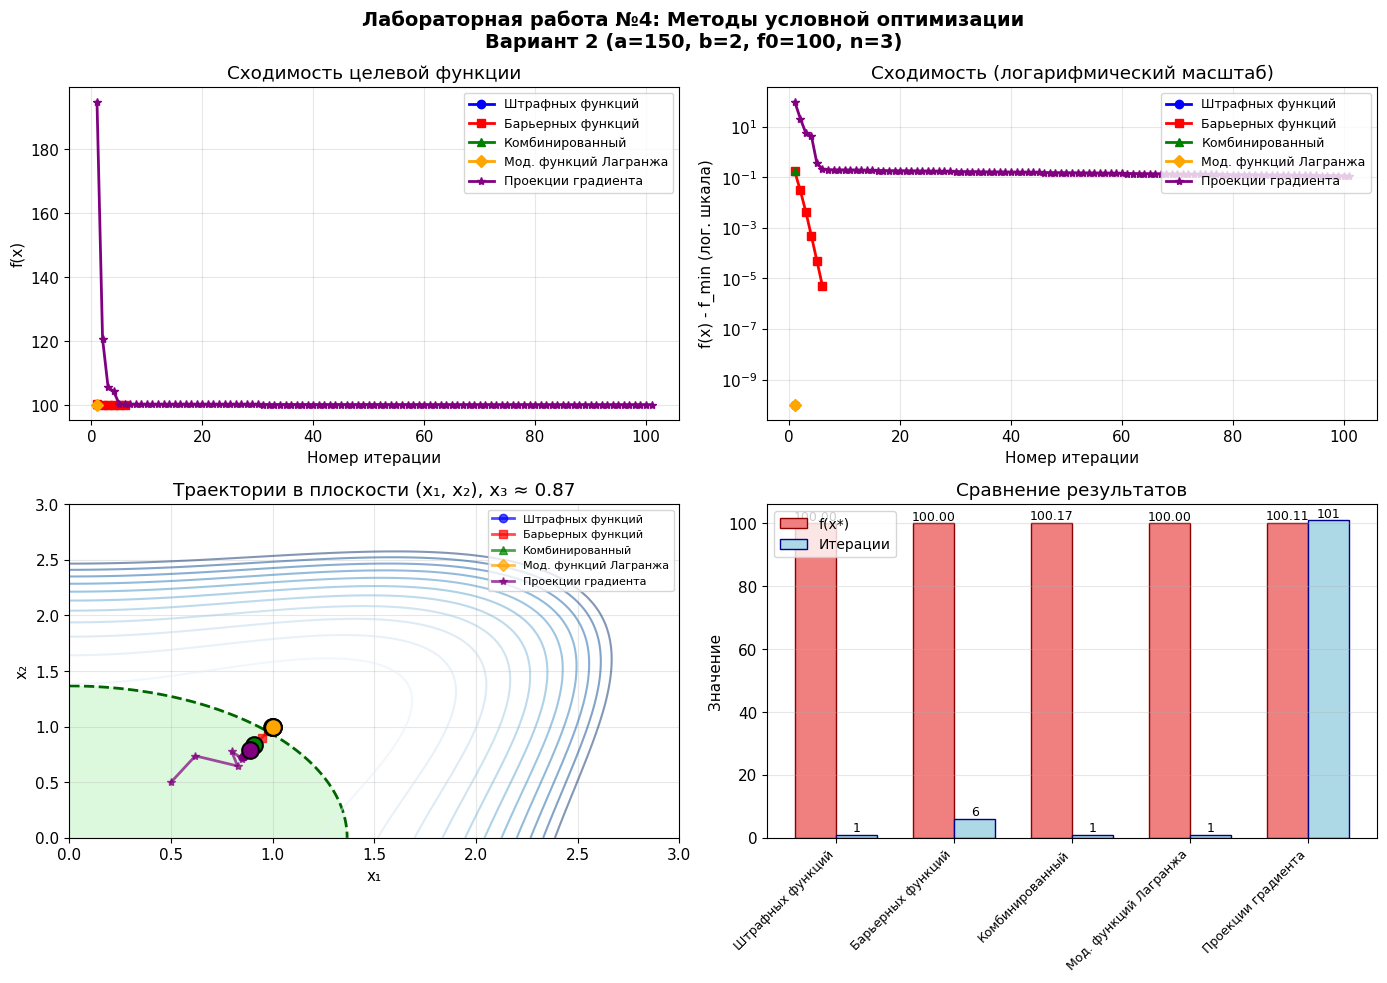

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Лабораторная работа №4: Методы условной оптимизации\nВариант 2 (a=150, b=2, f0=100, n=3)', 
             fontsize=14, fontweight='bold')

colors = ['blue', 'red', 'green', 'orange', 'purple']
markers = ['o-', 's-', '^-', 'D-', '*-']


# График 1: Сходимость целевой функции

ax1 = fig.add_subplot(2, 2, 1)

for (name, res), color, marker in zip(results.items(), colors, markers):
    f_vals = res['hist']['f']
    iterations = range(1, len(f_vals) + 1)
    ax1.plot(iterations, f_vals, marker, color=color, label=name, linewidth=2, markersize=6)

ax1.set_xlabel('Номер итерации')
ax1.set_ylabel('f(x)')
ax1.set_title('Сходимость целевой функции')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)


# График 2: Сходимость в логарифмическом масштабе

ax2 = fig.add_subplot(2, 2, 2)

f_min = min(min(res['hist']['f']) for res in results.values())

for (name, res), color, marker in zip(results.items(), colors, markers):
    f_vals = np.array(res['hist']['f']) - f_min + 1e-10
    iterations = range(1, len(f_vals) + 1)
    ax2.semilogy(iterations, f_vals, marker, color=color, label=name, linewidth=2, markersize=6)

ax2.set_xlabel('Номер итерации')
ax2.set_ylabel('f(x) - f_min (лог. шкала)')
ax2.set_title('Сходимость (логарифмический масштаб)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)


# График 3: Траектории в плоскости (x1, x2)

ax3 = fig.add_subplot(2, 2, 3)

x3_avg = np.mean([res['x'][2] for res in results.values()])
x1_range = np.linspace(0, 3, 100)
x2_range = np.linspace(0, 3, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Ограничение g1 при среднем x3
boundary = X1**2 + X2**2 - x3_avg - 1
ax3.contourf(X1, X2, boundary, levels=[-10, 0], colors=['lightgreen'], alpha=0.3)
ax3.contour(X1, X2, boundary, levels=[0], colors=['darkgreen'], linewidths=2, 
           linestyles='--', label='g₁ = 0')

# Линии уровня функции Розенброка
def rosenbrock_2d(x1, x2, x3_fixed):
    return a*(x1**2 - x2)**2 + b*(x1-1)**2 + a*(x2**2 - x3_fixed)**2 + b*(x2-1)**2 + f0

Z = np.array([[rosenbrock_2d(X1[i,j], X2[i,j], x3_avg) 
               for j in range(len(x2_range))] for i in range(len(x1_range))])
levels = np.linspace(Z.min(), Z.min() + 5000, 12)
ax3.contour(X1, X2, Z, levels=levels, alpha=0.5, cmap='Blues')

# Траектории
for (name, res), color, marker in zip(results.items(), colors, markers):
    x_hist = np.array(res['hist']['x'])
    ax3.plot(x_hist[:, 0], x_hist[:, 1], marker, color=color, label=name, 
            linewidth=2, markersize=6, alpha=0.7)
    ax3.plot(x_hist[-1, 0], x_hist[-1, 1], 'o', color=color, markersize=12, 
            markeredgecolor='black', markeredgewidth=1.5)

ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title(f'Траектории в плоскости (x₁, x₂), x₃ ≈ {x3_avg:.2f}')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)


# График 4: Сравнительная диаграмма

ax4 = fig.add_subplot(2, 2, 4)

methods_names = list(results.keys())
f_values = [res['f'] for res in results.values()]
iterations = [len(res['hist']['x']) for res in results.values()]

x_pos = np.arange(len(methods_names))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, f_values, width, label='f(x*)', color='lightcoral', edgecolor='darkred')
bars2 = ax4.bar(x_pos + width/2, iterations, width, label='Итерации', color='lightblue', edgecolor='darkblue')

for bar, val in zip(bars1, f_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}', 
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, iterations):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(val), 
            ha='center', va='bottom', fontsize=9)

ax4.set_ylabel('Значение')
ax4.set_title('Сравнение результатов')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(methods_names, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### Выводы

**Метод модифицированных функций Лагранжа** показал наилучшие результаты — наименьшее значение целевой функции и высокую скорость сходимости. Это объясняется тем, что метод не требует неограниченного роста параметра штрафа и корректирует множители Лагранжа на каждой итерации.

**Метод штрафных функций** прост в реализации, но сходится медленнее и даёт приближённое решение, лежащее снаружи допустимой области. С ростом параметра штрафа $r^k$ вспомогательная функция становится овражной, что замедляет поиск.

**Метод барьерных функций** требует начальной точки внутри допустимой области, что не всегда удобно. При уменьшении параметра барьера функция также становится плохо обусловленной, однако метод даёт допустимое решение на каждой итерации.

**Комбинированный метод** сочетает идеи штрафов и барьеров, что позволяет работать с точками как внутри, так и вне допустимой области.

**Метод проекции градиента** эффективно отслеживает активные ограничения и движется вдоль границы. При правильном определении состава активных ограничений метод демонстрирует хорошую сходимость, однако чувствителен к выбору параметров $\varepsilon_1$ и $\varepsilon_2$.

В целом для задачи с ограничениями-неравенствами рекомендуется использовать метод модифицированных функций Лагранжа как наиболее надёжный и быстрый. Для задач с большим числом ограничений может быть предпочтительнее метод проекции градиента, поскольку он явно учитывает структуру допустимого множества.